In [21]:
%load_ext autoreload
%autoreload 2

import sys, os, json, torch, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

# Reproducibility (Seeding for python, numpy, and torch)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORD_MAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
VAL_IMAGES_DIR = '../dataset/val2014'
DATASET_JSON = '../dataset/caption_datasets/dataset_coco.json'

SAMPLE_SIZE = 1000
BEAM_SIZE = 3

with open(WORD_MAP_PATH, 'r') as j: word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

checkpoint = torch.load(MODEL_PATH, map_location=str(DEVICE), weights_only=False)
decoder, encoder = checkpoint['decoder'].to(DEVICE).eval(), checkpoint['encoder'].to(DEVICE).eval()

# Rigorous sampling (Preventing silent file skipping)
with open(DATASET_JSON, 'r') as j:
    all_test_images = [img for img in json.load(j)['images'] if img['split'] == 'test']

valid_images = [img for img in all_test_images if os.path.exists(os.path.join(VAL_IMAGES_DIR, img['filename']))]
sampled_images = random.sample(valid_images, min(SAMPLE_SIZE, len(valid_images)))
references_dict = {img['filename']: [c['tokens'] for c in img['sentences']] for img in sampled_images}

print(f"Rigorous sampling complete: Exactly {len(references_dict)} images ready for perturbation testing.")

Rigorous sampling complete: Exactly 1000 images ready for perturbation testing.


In [22]:
def apply_perturbation(image_path, p_type, severity):
    """
    Reads image, NORMALIZES SIZE to 256x256 (CRITICAL!), 
    and applies perturbation with given severity.
    """
    img = Image.open(image_path).convert('RGB')
    
    img = img.resize((256, 256), Image.LANCZOS)
    
    if p_type == "Clean":
        return img
    elif p_type == "Gaussian_Blur":
        return img.filter(ImageFilter.GaussianBlur(radius=severity))
    elif p_type == "Low_Contrast":
        return ImageEnhance.Contrast(img).enhance(severity)
    elif p_type == "Gaussian_Noise":
        img_np = np.array(img).astype(np.float32)
        noise = np.random.normal(0, severity, img_np.shape)
        return Image.fromarray(np.clip(img_np + noise, 0, 255).astype(np.uint8))
    elif p_type == "Rotation":
        return img.rotate(severity, fillcolor=(0, 0, 0))
        
    return img

def bootstrap_bleu(actual_refs, actual_hyps, n_iterations=1000):
    """Calculating 95% Confidence Intervals (CI) for BLEU-4."""
    scores = []
    n = len(actual_hyps)
    for _ in range(n_iterations):
        indices = np.random.choice(n, n, replace=True)
        scores.append(corpus_bleu([actual_refs[i] for i in indices], [actual_hyps[i] for i in indices], weights=(0.25, 0.25, 0.25, 0.25)))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

In [23]:
# Test suite: (Type, Parameter, Label for results)
test_suite = [
    ("Clean", 0, "Clean (Baseline)"),
    ("Gaussian_Blur", 2, "Blur (r=2)"),
    ("Gaussian_Blur", 5, "Blur (r=5)"),
    ("Gaussian_Noise", 20, "Noise (σ=20)"),
    ("Gaussian_Noise", 50, "Noise (σ=50)"),
    ("Low_Contrast", 0.5, "Contrast (50%)"),
    ("Low_Contrast", 0.2, "Contrast (20%)"),
    ("Rotation", 15, "Rotate (15°)"),
    ("Rotation", 45, "Rotate (45°)")
]

robustness_results = {}

for p_type, severity, label in test_suite:
    actual_refs, actual_hyps = [], []
    
    for filename, refs in tqdm(references_dict.items(), desc=f"Eval: {label}"):
        filepath = os.path.join(VAL_IMAGES_DIR, filename)
        
        # Generation perturbation and captioning
        img_ram = apply_perturbation(filepath, p_type, severity)
        seq, _ = caption_image_beam_search(encoder, decoder, img_ram, word_map, BEAM_SIZE)
        
        hypothesis = [rev_word_map[w] for w in seq if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        actual_refs.append(refs)
        actual_hyps.append(hypothesis)
        
    b4 = corpus_bleu(actual_refs, actual_hyps, weights=(0.25, 0.25, 0.25, 0.25))
    ci_low, ci_high = bootstrap_bleu(actual_refs, actual_hyps)
    
    robustness_results[label] = {"BLEU4": b4, "CI_Lower": ci_low, "CI_Upper": ci_high}

Eval: Rotate (45°): 100%|██████████| 1000/1000 [00:29<00:00, 33.45it/s]


,BLEU4,CI_Lower,CI_Upper,Error_Low,Error_High
Clean (Baseline),0.336315,0.319597,0.352175,0.016718,0.015860
Blur (r=2),0.256687,0.239931,0.272532,0.016756,0.015845
Blur (r=5),0.042481,0.035755,0.048595,0.006725,0.006114
Noise (σ=20),0.280816,0.263553,0.296750,0.017264,0.015933
Noise (σ=50),0.141379,0.128033,0.153011,0.013346,0.011632
Contrast (50%),0.318825,0.301955,0.335078,0.016869,0.016253
Contrast (20%),0.274734,0.257797,0.289833,0.016937,0.015099
Rotate (15°),0.276222,0.259654,0.292726,0.016568,0.016504
Rotate (45°),0.202089,0.186728,0.218040,0.015361,0.015950


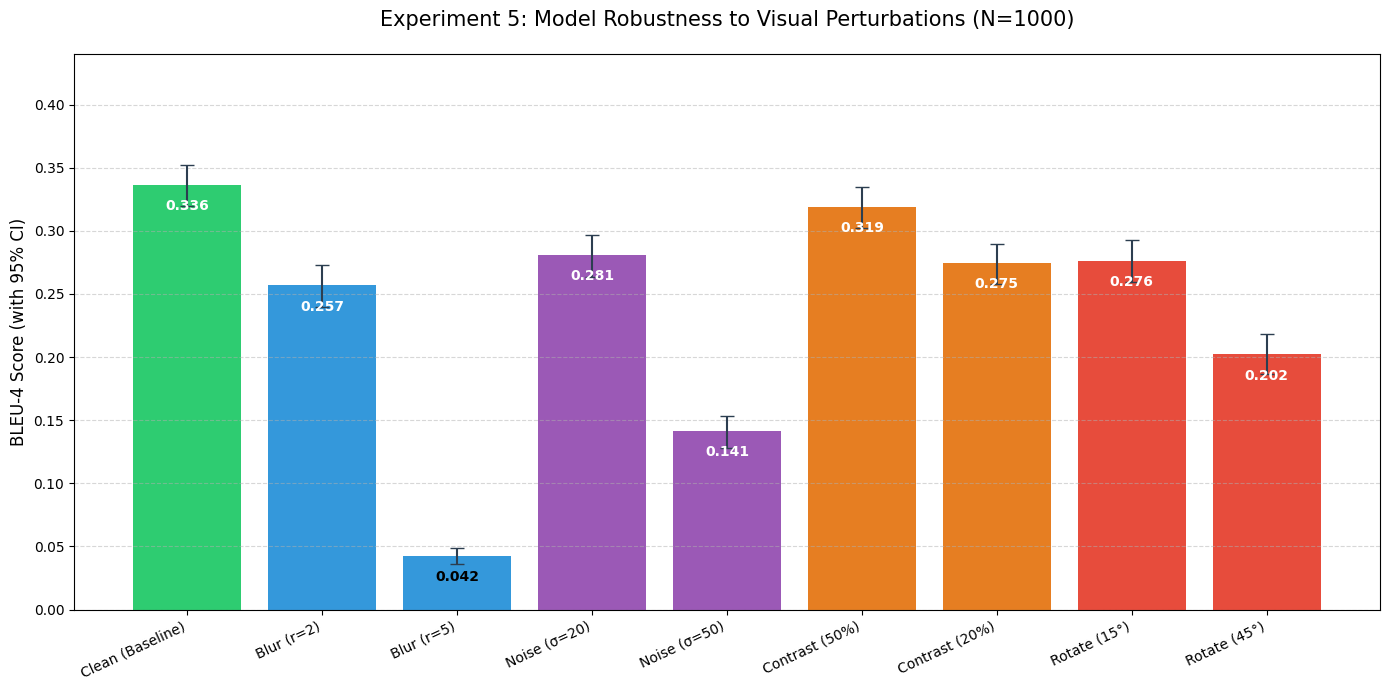

In [24]:
df_rob = pd.DataFrame.from_dict(robustness_results, orient='index')
df_rob['Error_Low'] = df_rob['BLEU4'] - df_rob['CI_Lower']
df_rob['Error_High'] = df_rob['CI_Upper'] - df_rob['BLEU4']
display(df_rob)

fig, ax = plt.subplots(figsize=(14, 7))

# Enhanced visualization (Bar chart with error bars and color coding)
labels = df_rob.index
colors = ['#2ecc71'] + ['#3498db']*2 + ['#9b59b6']*2 + ['#e67e22']*2 + ['#e74c3c']*2

bars = ax.bar(labels, df_rob['BLEU4'], color=colors, yerr=[df_rob['Error_Low'], df_rob['Error_High']], capsize=5, ecolor='#2c3e50')

ax.set_title(f'Experiment 5: Model Robustness to Visual Perturbations (N={SAMPLE_SIZE})', fontsize=15, pad=20)
ax.set_ylabel('BLEU-4 Score (with 95% CI)', fontsize=12)
ax.set_ylim(0, max(df_rob['CI_Upper']) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=25, ha='right')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval - 0.02, f"{yval:.3f}", ha='center', color='white' if yval > 0.05 else 'black', fontweight='bold')

plt.tight_layout()
plt.show()

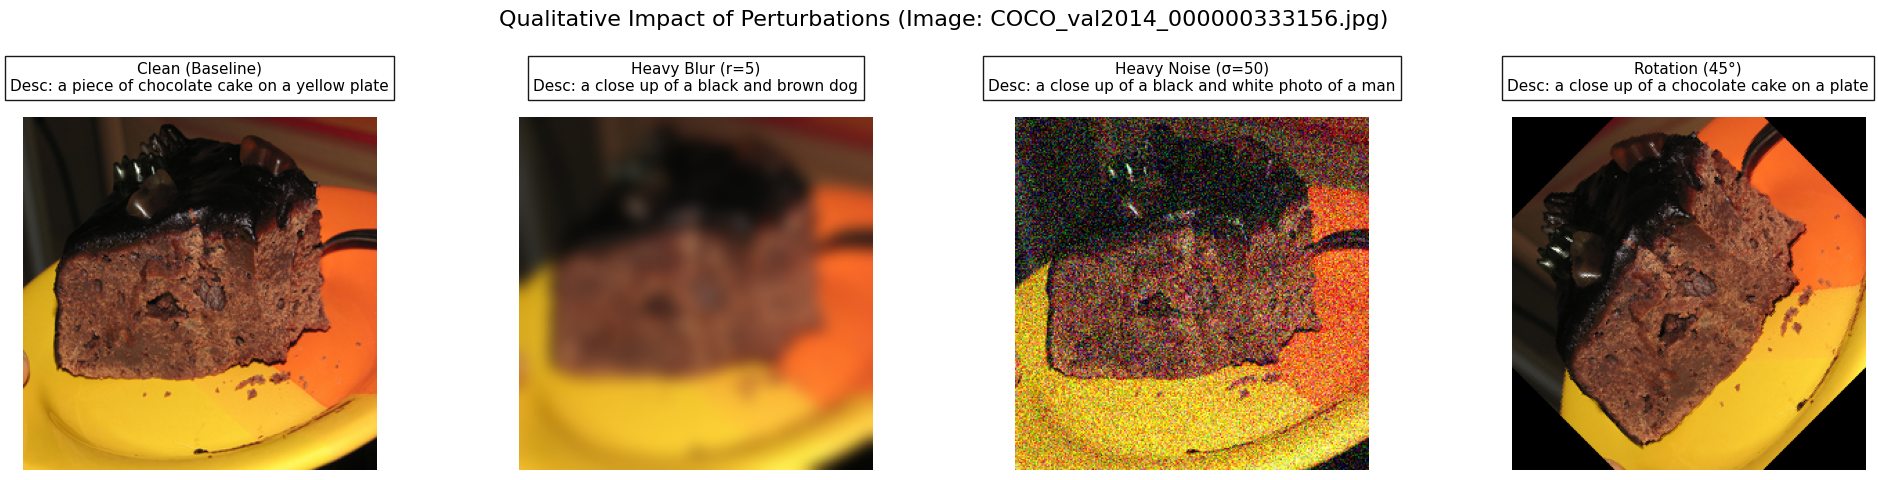

In [25]:
# Qualitative analysis - visualizing the impact of perturbations on a random image
sample_filename = random.choice(list(references_dict.keys()))
sample_path = os.path.join(VAL_IMAGES_DIR, sample_filename)

demo_suite = [
    ("Clean", 0, "Clean (Baseline)"),
    ("Gaussian_Blur", 5, "Heavy Blur (r=5)"),
    ("Gaussian_Noise", 50, "Heavy Noise (σ=50)"),
    ("Rotation", 45, "Rotation (45°)")
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

fig.suptitle(f'Qualitative Impact of Perturbations (Image: {sample_filename})', fontsize=16, y=0.95)

for ax, (p_type, severity, label) in zip(axes, demo_suite):
    img = apply_perturbation(sample_path, p_type, severity)
    seq, _ = caption_image_beam_search(encoder, decoder, img, word_map, BEAM_SIZE)
    hyp = " ".join([rev_word_map[w] for w in seq if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])
    
    ax.imshow(img)
    ax.axis('off')
    
    ax.set_title(f"{label}\nDesc: {hyp}", fontsize=11, wrap=True, pad=20, bbox=dict(facecolor='white', alpha=0.9))

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()